

# Clustering with K-means 


For this project we are going explore the K-Means clustering method
  
Using a small example data set, we will implement the algorithm and visualize the results.

In [1]:
#Importing libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

# K-Means

We will implement a Basic K-means Algorithm, and apply that algorithm to a small data set in the `data_kmeans.csv` file. We will build up some helper functions along the way, test them, and put it all together to apply to our small example data set. 

In [2]:
# loading in our toy data
df_kmeans = pd.read_csv('data_kmeans.csv')

## Writing a function that returns `k` random rows from a data frame

To initialize the centroids, we pick `k` random points from a data frame. The function `init_centroids( df_data, k )` accepts two parameters: a data frame `df_data`, and an integer `k`, and returns the initial centroids for our k-means algorithm.

In [3]:
def init_centroids( df_data, k ):
    df_centroid = df_data.sample(n = k, random_state=42)
    df_centroid = df_centroid.reset_index(drop=True)
     
    return df_centroid

In [4]:
# Testing our init centroid function
df_centroids = init_centroids( df_kmeans, 7)
df_centroids

,x,y
0,-0.633437,0.488756
1,-0.597736,0.632194
2,-0.635867,0.166613
3,-0.539351,-0.875532
4,-0.588597,0.293062
5,-0.127985,-0.136639
6,0.342579,0.211717


## Writing a function to assign every row in a data frame to a centroid 

This function `assign_to_centroid`, accepts two parameters: a data frame, `df_data`, that represents our data to be clustered, and the data frame, `df_centroids`, which is of length `k` and contains the current centroids for our clusters.  The function returns a series of the same length of `df_data` that contains the index of the closest centroid in `df_centroid`.  We will use Euclidean distance as your distance measure. 


In [5]:
#function to calculate the distance between currnt and centriod points
def distance(current, centroid):
    dist = ((current["x"] - centroid["x"])**2 + (current["y"] - centroid["y"])**2)**(1/2)
    return dist

#function to assign every data point to a centroid
def assign_to_centroid( df_data, df_centroids ):
    
    df_closest = np.array([])
    for index, current_row in df_data.iterrows():
        centroid_dist_list = []
        
        for index, centroid_row in df_centroids.iterrows():
            centroid_dist = distance(current_row, centroid_row)
            centroid_dist_list.append(centroid_dist)

        min_idx = centroid_dist_list.index(min(centroid_dist_list))

        df_closest = np.append(df_closest, min_idx) 

    df_closest = pd.Series(df_closest)
    
    for i in range(7):
        df_k = df_data[df_closest == i]
        
    return df_closest   

In [6]:
# Check how many data points were assigned to each centroid
s_centroid_assignment = assign_to_centroid( df_kmeans, df_centroids )
s_centroid_assignment.value_counts()

6.0    126
1.0     94
3.0     71
5.0     58
0.0     53
2.0     26
4.0     22
dtype: int64

## Writing a function that recomputes the centroids

The function `compute_centroids` takes two parameters: the data frame, `df_data` containing the data being clustered, and a series of the same length that contains the label of the assigned centroid for every row in df_data, `s_centroid_assignment`. The function returns the a data frame containing the centroids (mean) value for each unique centroid. 

Note that the indices in the returned data frame should correspond to the unique values in `s_centroid_assignment`.  For example, if I found the mean value of df_data using the slice corresponding to `s_centroid_assigment == 2`, then the centroid should be in the returned data frame at `.iloc[2]`. 


In [7]:
def compute_centroids( df_data, s_centroid_assignment ):
    df_new_centroids = df_centroids.copy()

    df_new_centroids = df_new_centroids[:(len(s_centroid_assignment.value_counts()))]

    for i in range(len(s_centroid_assignment.value_counts())):
        df_k = df_data[s_centroid_assignment == i]
        df_k_mean = df_k.mean().to_numpy()
        df_k_mean = [df_k_mean[0], df_k_mean[1]]

        df_new_centroids.iloc[i]["x"] = df_k_mean[0]
        df_new_centroids.iloc[i]["y"] = df_k_mean[1]
        
    return df_new_centroids

In [8]:
# Testing it out
df_new_centroids = compute_centroids( df_kmeans, s_centroid_assignment)
df_new_centroids

,x,y
0,-0.715983,0.500552
1,-0.721574,0.708343
2,-0.738268,-0.113830
3,-0.696694,-0.699028
4,-0.546913,0.321364
5,-0.102365,-0.188876
6,0.523364,0.238569


## Writing a function that compares two centroid data frames

Writing a function `compare_centroids` that is given 2 centroid data frames, `df_centroid_a`, and `df_centroid_b` as parameters and returns `True` or `False` indicating if the centroids at each unique index in the data frame are equal. Using the [equals](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.Series.equals.html) method to compare equality of pandas Series objects. 

In [9]:
def compare_centroids( df_centroid_a, df_centroid_b ):  
    return df_centroid_a.equals(df_centroid_b)

In [10]:
# Testing it out, should print True followed by False
print(compare_centroids( df_new_centroids, df_new_centroids ))
print(compare_centroids( df_new_centroids, df_centroids ))

True
False


## Writing a function that implements k-means

The function `k_means`, takes in parameters 2 values, a data frame with values to cluster, `df_data`, and the number of clusters to form, `k`.  The function returns a series of data of the same length as `df_data` that contains the cluster assignment for each row of data. We will use the helper functions defined previously.

In [11]:
def k_means( df_data, k ):
    df_k_centroids = init_centroids( df_data, k )
    
    while True:
        s_centroid_assignments = assign_to_centroid( df_data, df_k_centroids )
        df_k_new_centroids = compute_centroids( df_data, s_centroid_assignments)
    
        if compare_centroids( df_k_centroids, df_k_new_centroids):
            break
        else:
            df_k_centroids = df_k_new_centroids
    return s_centroid_assignments

In [12]:
# Calling k_means with k = 5 to test
s_cluster_assignment = k_means( df_kmeans, 5)
s_cluster_assignment.value_counts()

0.0    178
3.0     89
2.0     74
4.0     63
1.0     46
dtype: int64

## Ploting the results

Ploting the points in the `df_kmeans` data frame using a 2-D scatter plot, with a different color for each cluster.

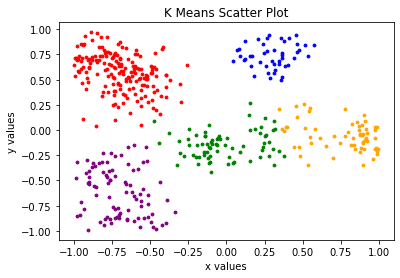

In [13]:
# Ploting each cluster
color = ["red", "blue", "green", "purple", "orange"]
for i in range(len(s_cluster_assignment.value_counts())):
    df_k = df_kmeans[s_cluster_assignment == i]
    plt.scatter(df_k["x"], df_k["y"], s=8, color = color[i])
plt.xlabel("x values")
plt.ylabel("y values")
plt.title("K Means Scatter Plot")
plt.show()